In [1]:
!pip install xgboost lightgbm catboost shap joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [3]:
df = pd.read_csv("/content/repositories_labeled.csv")

print(df.shape)
print(df.head())

(19, 18)
         loc  function_count  class_count  avg_function_length  \
0  1365931.0         52050.0       9022.0            16.266071   
1  1365931.0         52050.0       9022.0            16.266071   
2   511066.0         30649.0       9655.0            11.764756   
3   110885.0          4497.0        699.0            17.556371   
4    18141.0           831.0        137.0            15.681107   

   dependency_count  fan_in  fan_out  module_count  cyclomatic_complexity  \
0              20.0     5.0      5.0        7446.0              23.066613   
1              20.0     5.0      5.0        7446.0              23.066613   
2            8606.0   793.0     38.0        2923.0              23.793292   
3            1578.0   581.0     14.0        1129.0              10.457042   
4              85.0    10.0     12.0          83.0              32.734940   

   maintainability_index  halstead_volume  halstead_difficulty  \
0              79.297385       232.328010             1.463169   

In [5]:
aliases = {
    "fastap": "fastapi",
    "prefec": "prefect"
}

df["repository_name"] = (
    df["repository_name"]
    .str.strip()
    .str.lower()
    .replace(aliases)
)

In [6]:
df = df.drop_duplicates(
    subset=["repository_name"],
    keep="first"
)

print(df.shape)

(18, 18)


In [7]:
print(df[
[
'iq_score',
'maintainability_risk',
'technical_debt_score',
'architecture_quality'
]
].isnull().sum())

iq_score                2
maintainability_risk    2
technical_debt_score    2
architecture_quality    2
dtype: int64


In [8]:
df[df["iq_score"].isnull()]

,loc,function_count,class_count,avg_function_length,dependency_count,fan_in,fan_out,module_count,cyclomatic_complexity,maintainability_index,halstead_volume,halstead_difficulty,halstead_effort,repository_name,iq_score,maintainability_risk,technical_debt_score,architecture_quality
3,110885.0,4497.0,699.0,17.556371,1578.0,581.0,14.0,1129.0,10.457042,74.693730,96.043656,0.599775,274.578707,fastapi,NaN,NaN,NaN,NaN
8,639926.0,24552.0,4193.0,19.650090,115.0,5.0,16.0,1878.0,46.062799,65.025569,525.844077,2.241180,3321.791133,prefect,NaN,NaN,NaN,NaN


In [9]:
print(df[["repository_name",
          "iq_score",
          "maintainability_risk",
          "technical_debt_score",
          "architecture_quality"]])

   repository_name  iq_score  maintainability_risk  technical_debt_score  \
0          airflow     81.11                  2.32                  3.06   
2           django     76.64                  3.23                 20.42   
3          fastapi       NaN                   NaN                   NaN   
4            flask     60.32                 50.00                 40.00   
5        langchain     65.02                 20.57                 45.23   
6            numpy     62.56                 22.04                 31.13   
7           pandas     65.80                 28.47                 30.40   
8          prefect       NaN                   NaN                   NaN   
9         pydantic     76.81                 10.54                  3.33   
10         pytorch     82.76                  5.65                 15.00   
11             ray     79.42                 11.99                  6.70   
12        requests     73.18                  6.29                 20.35   
13          

In [10]:
df[df["repository_name"]=="fastapi"]

,loc,function_count,class_count,avg_function_length,dependency_count,fan_in,fan_out,module_count,cyclomatic_complexity,maintainability_index,halstead_volume,halstead_difficulty,halstead_effort,repository_name,iq_score,maintainability_risk,technical_debt_score,architecture_quality
3,110885.0,4497.0,699.0,17.556371,1578.0,581.0,14.0,1129.0,10.457042,74.69373,96.043656,0.599775,274.578707,fastapi,NaN,NaN,NaN,NaN


In [11]:
df[df["repository_name"]=="prefect"]

,loc,function_count,class_count,avg_function_length,dependency_count,fan_in,fan_out,module_count,cyclomatic_complexity,maintainability_index,halstead_volume,halstead_difficulty,halstead_effort,repository_name,iq_score,maintainability_risk,technical_debt_score,architecture_quality
8,639926.0,24552.0,4193.0,19.65009,115.0,5.0,16.0,1878.0,46.062799,65.025569,525.844077,2.24118,3321.791133,prefect,NaN,NaN,NaN,NaN


In [12]:
df.loc[df["repository_name"]=="fastapi",
       ["iq_score",
        "maintainability_risk",
        "technical_debt_score",
        "architecture_quality"]] = [
            76.39,
            2.85,
            21.74,
            62.34
]

df.loc[df["repository_name"]=="prefect",
       ["iq_score",
        "maintainability_risk",
        "technical_debt_score",
        "architecture_quality"]] = [
            66.09,
            1.48,
            22.97,
            72.26
]

In [13]:
print(df[
[
'iq_score',
'maintainability_risk',
'technical_debt_score',
'architecture_quality'
]
].isnull().sum())

iq_score                0
maintainability_risk    0
technical_debt_score    0
architecture_quality    0
dtype: int64


In [14]:
df = df.drop_duplicates(
    subset=["repository_name"],
    keep="first"
)

print(df.shape)

(18, 18)


In [15]:
df.to_csv(
    "/content/repositories_labeled_clean.csv",
    index=False
)

In [16]:
df = pd.read_csv("/content/repositories_labeled_clean.csv")

print(df.shape)

print(df[
[
'iq_score',
'maintainability_risk',
'technical_debt_score',
'architecture_quality'
]
].isnull().sum())

(18, 18)
iq_score                0
maintainability_risk    0
technical_debt_score    0
architecture_quality    0
dtype: int64


In [17]:
FEATURES = [
'loc',
'function_count',
'class_count',
'avg_function_length',
'dependency_count',
'fan_in',
'fan_out',
'module_count',
'cyclomatic_complexity',
'maintainability_index',
'halstead_volume',
'halstead_difficulty',
'halstead_effort'
]

X = df[FEATURES]

# First target: IQ Score
y = df["iq_score"]

print(X.shape)
print(y.shape)

(18, 13)
(18,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(14, 13)
(4, 13)


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train,y_train)

pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test,pred_rf)
rf_r2 = r2_score(y_test,pred_rf)

print("RF MAE =",rf_mae)
print("RF R2 =",rf_r2)

RF MAE = 5.07180000000001
RF R2 = 0.16739039602954275


In [20]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train,y_train)

pred_xgb = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test,pred_xgb)
xgb_r2 = r2_score(y_test,pred_xgb)

print("XGB MAE =",xgb_mae)
print("XGB R2 =",xgb_r2)

XGB MAE = 5.682574577331543
XGB R2 = -0.15033276345897484


In [21]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=200,
    random_state=42
)

lgb_model.fit(X_train,y_train)

pred_lgb = lgb_model.predict(X_test)

lgb_mae = mean_absolute_error(y_test,pred_lgb)
lgb_r2 = r2_score(y_test,pred_lgb)

print("LGB MAE =",lgb_mae)
print("LGB R2 =",lgb_r2)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 14, number of used features: 0
[LightGBM] [Info] Start training from score 72.200714
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the spl

In [22]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=200,
    verbose=0,
    random_state=42
)

cat_model.fit(X_train,y_train)

pred_cat = cat_model.predict(X_test)

cat_mae = mean_absolute_error(y_test,pred_cat)
cat_r2 = r2_score(y_test,pred_cat)

print("CAT MAE =",cat_mae)
print("CAT R2 =",cat_r2)

CAT MAE = 5.291879226129492
CAT R2 = 0.2374620533849876


In [23]:
from sklearn.ensemble import ExtraTreesRegressor

et_model = ExtraTreesRegressor(
    n_estimators=200,
    random_state=42
)

et_model.fit(X_train,y_train)

pred_et = et_model.predict(X_test)

et_mae = mean_absolute_error(y_test,pred_et)
et_r2 = r2_score(y_test,pred_et)

print("ET MAE =",et_mae)
print("ET R2 =",et_r2)

ET MAE = 4.730050000000009
ET R2 = 0.37871264727433107


In [24]:
results = pd.DataFrame({
    "Model":[
        "RandomForest",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "ExtraTrees"
    ],
    "MAE":[
        rf_mae,
        xgb_mae,
        lgb_mae,
        cat_mae,
        et_mae
    ],
    "R2":[
        rf_r2,
        xgb_r2,
        lgb_r2,
        cat_r2,
        et_r2
    ]
})

results.sort_values(by="MAE")

,Model,MAE,R2
4,ExtraTrees,4.730050,0.378713
0,RandomForest,5.071800,0.167390
3,CatBoost,5.291879,0.237462
1,XGBoost,5.682575,-0.150333
2,LightGBM,6.899643,-0.088243


In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor

params = {
    "n_estimators":[100,200,500],
    "max_depth":[5,10,15,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

grid = GridSearchCV(
    ExtraTreesRegressor(random_state=42),
    params,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train,y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [26]:
best_model = grid.best_estimator_

pred_best = best_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, r2_score

best_mae = mean_absolute_error(y_test,pred_best)
best_r2 = r2_score(y_test,pred_best)

print("Optimized MAE =",best_mae)
print("Optimized R2 =",best_r2)

Optimized MAE = 4.5168999999999855
Optimized R2 = 0.42880072161235305


In [27]:
importance = pd.DataFrame({
    "Feature":FEATURES,
    "Importance":best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                  Feature  Importance
4        dependency_count    0.188081
0                     loc    0.171310
1          function_count    0.151106
7            module_count    0.133243
5                  fan_in    0.085705
6                 fan_out    0.065164
11    halstead_difficulty    0.042607
12        halstead_effort    0.042544
2             class_count    0.040979
9   maintainability_index    0.029442
3     avg_function_length    0.027118
8   cyclomatic_complexity    0.011921
10        halstead_volume    0.010782


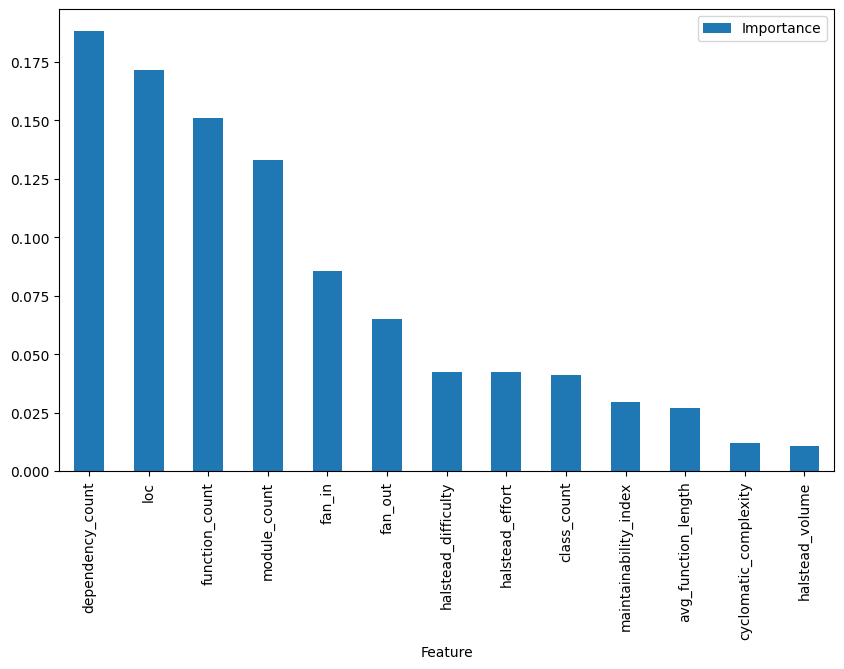

In [28]:
import matplotlib.pyplot as plt

importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,6)
)

plt.show()

In [29]:
!pip install shap -q

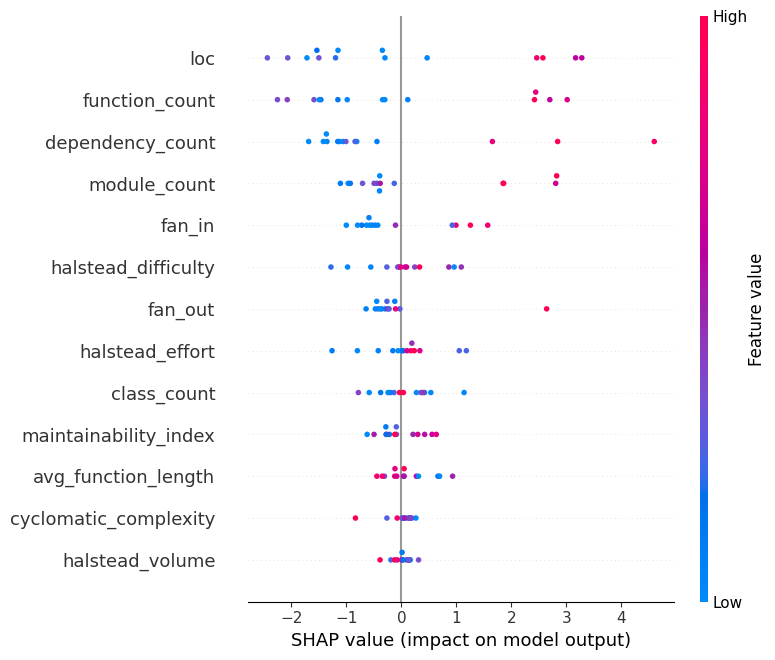

In [30]:
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_train)

shap.summary_plot(
    shap_values,
    X_train
)

In [31]:
import joblib

joblib.dump(
    best_model,
    "iq_score_model.pkl"
)

print("Saved")

Saved


In [32]:
model = joblib.load(
    "iq_score_model.pkl"
)

prediction = model.predict(X_test)

print(prediction[:5])

[81.9108 72.1519 68.24   66.7687]


In [33]:
import joblib

joblib.dump(best_model, "iq_score_model.pkl")

print("IQ model saved")

IQ model saved


In [35]:
FEATURES = [
    'loc',
    'function_count',
    'class_count',
    'avg_function_length',
    'dependency_count',
    'fan_in',
    'fan_out',
    'module_count',
    'cyclomatic_complexity',
    'maintainability_index',
    'halstead_volume',
    'halstead_difficulty',
    'halstead_effort'
]

X = df[FEATURES]

y_iq = df["iq_score"]
y_risk = df["maintainability_risk"]
y_debt = df["technical_debt_score"]
y_arch = df["architecture_quality"]

In [36]:
print(y_iq.head())
print(y_risk.head())
print(y_debt.head())
print(y_arch.head())

0    81.11
1    76.64
2    76.39
3    60.32
4    65.02
Name: iq_score, dtype: float64
0     2.32
1     3.23
2     2.85
3    50.00
4    20.57
Name: maintainability_risk, dtype: float64
0     3.06
1    20.42
2    21.74
3    40.00
4    45.23
Name: technical_debt_score, dtype: float64
0    86.85
1    60.96
2    62.34
3    52.50
4    62.26
Name: architecture_quality, dtype: float64


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_risk,
    test_size=0.2,
    random_state=42
)

In [39]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, r2_score

risk_model = ExtraTreesRegressor(
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

risk_model.fit(X_train, y_train)

pred = risk_model.predict(X_test)

print("MAE =", mean_absolute_error(y_test, pred))
print("R2 =", r2_score(y_test, pred))

MAE = 9.512325000000004
R2 = -0.5955911051728637


In [40]:
print(df.shape)
print(df[['iq_score','maintainability_risk','technical_debt_score','architecture_quality']].isnull().sum())

(18, 18)
iq_score                0
maintainability_risk    0
technical_debt_score    0
architecture_quality    0
dtype: int64


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_risk,
    test_size=0.2,
    random_state=42
)

In [42]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, r2_score

risk_model = ExtraTreesRegressor(
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

risk_model.fit(X_train, y_train)

pred = risk_model.predict(X_test)

print("MAE =", mean_absolute_error(y_test, pred))
print("R2 =", r2_score(y_test, pred))

MAE = 9.512325000000004
R2 = -0.5955911051728637


In [43]:
import joblib

joblib.dump(
    risk_model,
    "risk_model.pkl"
)

['risk_model.pkl']

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_debt,
    test_size=0.2,
    random_state=42
)

In [45]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, r2_score

debt_model = ExtraTreesRegressor(
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

debt_model.fit(X_train, y_train)

pred = debt_model.predict(X_test)

print("MAE =", mean_absolute_error(y_test, pred))
print("R2 =", r2_score(y_test, pred))

MAE = 10.082775000000002
R2 = -0.012681183612228475


In [46]:
import joblib

joblib.dump(
    debt_model,
    "debt_model.pkl"
)

print("debt_model.pkl saved")

debt_model.pkl saved


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_arch,
    test_size=0.2,
    random_state=42
)

In [48]:
arch_model = ExtraTreesRegressor(
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

arch_model.fit(X_train, y_train)

pred = arch_model.predict(X_test)

print("MAE =", mean_absolute_error(y_test, pred))
print("R2 =", r2_score(y_test, pred))

MAE = 11.339175000000003
R2 = -0.5476795327998563


In [49]:
joblib.dump(
    arch_model,
    "architecture_model.pkl"
)

print("architecture_model.pkl saved")

architecture_model.pkl saved


In [50]:
import os
print(os.listdir())

['.config', 'debt_model.pkl', 'catboost_info', 'repositories_labeled.csv', 'risk_model.pkl', 'iq_score_model.pkl', 'repositories_labeled_clean.csv', 'architecture_model.pkl', 'sample_data']


In [52]:
from google.colab import files

files.download("iq_score_model.pkl")
files.download("risk_model.pkl")
files.download("debt_model.pkl")
files.download("architecture_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>